# Fase 20: Análise das métricas dos áudios
Esse notebook analisa as métricas dos áudios


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

AUDIO_INFOS_DIR = "../data/qualidade_audios.csv"

df = pd.read_csv(AUDIO_INFOS_DIR)

# Coluna regiões de silêncio normalizada
df['silencio/tempo'] = df['regioes_silencio'] / df['duracao_segundos']
display(df)

,arquivo,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio,silencio/tempo
0,-89_5bDU5ko.mp3,54.566896,48000,0.087395,0.848866,0.102955,28.500414,0.068936,3,0.054978
1,LPDJollYuAc.mp3,12.968354,48000,0.290967,1.135026,0.256353,48.810177,0.022853,0,0.000000
2,zu1dIUoGd1g.mp3,706.880000,48000,0.044159,0.544028,0.081170,31.315220,0.075895,19,0.026879
3,0DQ82ua1GqQ.mp3,53.487167,48000,0.103145,0.984857,0.104731,37.229790,0.035058,0,0.000000
4,q2LIyyDKeOU.mp3,60.000979,48000,0.131033,1.044674,0.125430,51.049328,0.042408,0,0.000000
...,...,...,...,...,...,...,...,...,...,...
8968,AN4cFw5rBBU.mp3,37.848979,48000,0.061322,0.792349,0.077393,26.758072,0.031574,4,0.105683
8969,pUfLK1jrglg.mp3,85.844188,48000,0.030217,0.389398,0.077599,34.001556,0.018390,1,0.011649
8970,63lBbV42njg.mp3,45.708500,48000,0.104041,1.014510,0.102553,27.954025,0.061560,0,0.000000
8971,1jOpENTEC4A.mp3,4715.067229,48000,0.048428,0.990683,0.048883,32.209175,0.040369,861,0.182606


Valores nulos

In [2]:
print("\nExiste algum valor nulo no DataFrame inteiro?")
print(df.isnull().any().any())

print("\nLinhas do DataFrame com valores nulos:")
print(df[df.isnull().any(axis=1)])


Existe algum valor nulo no DataFrame inteiro?
True

Linhas do DataFrame com valores nulos:
              arquivo  duracao_segundos  frequencia_amostragem  \
688   WaFwAZxZ6bA.mp3          4.806542                  48000   
1381  vRQhKzPv_10.mp3          6.083646                  48000   
1433  K8y18trlUP8.mp3         30.011792                  48000   
1807  AM_pP8L0Cag.mp3          6.013979                  48000   
2196  r1hS_CGQF_w.mp3          2.020146                  48000   
3057  NeU6-Ps974k.mp3         52.709313                  48000   
3333  WQ9kdjBxq7Y.mp3         60.000979                  48000   
3367  tq4udeCZ-sw.mp3         11.006271                  48000   
3587  HgJpsG0J9iQ.mp3         15.000979                  48000   
3646  gp0-lg_kpMM.mp3          6.083646                  48000   
5800  uBPANTHe1CU.mp3        143.360000                  48000   
5981  qvo7pXzZtTo.mp3        131.584021                  48000   
6470  RCPwUQfRlT4.mp3         15.046542           

Linhas com valores nulos

In [3]:
df_temp = df.copy()
df_temp.replace([np.inf,-np.inf],np.nan,inplace=True)

metricas = ['duracao_segundos', 'frequencia_amostragem', 'amplitude_media','amplitude_maxima','amplitude_ratio (mean/max)','snr_estimado_db','zero_crossing_rate','silencio/tempo']  # substitua pelas suas métricas

# Pega as linhas que tiverem valores nulos
linhas_com_problema = df_temp[df_temp[metricas].isnull().any(axis=1)]
display(linhas_com_problema)

,arquivo,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio,silencio/tempo
688,WaFwAZxZ6bA.mp3,4.806542,48000,0.0,0.0,NaN,NaN,0.0,0,0.0
1381,vRQhKzPv_10.mp3,6.083646,48000,0.0,0.0,NaN,NaN,0.0,0,0.0
1433,K8y18trlUP8.mp3,30.011792,48000,0.0,0.0,NaN,NaN,0.0,0,0.0
1807,AM_pP8L0Cag.mp3,6.013979,48000,0.0,0.0,NaN,NaN,0.0,0,0.0
2196,r1hS_CGQF_w.mp3,2.020146,48000,0.0,0.0,NaN,NaN,0.0,0,0.0
3057,NeU6-Ps974k.mp3,52.709313,48000,0.0,0.0,NaN,NaN,0.0,0,0.0
3333,WQ9kdjBxq7Y.mp3,60.000979,48000,0.0,0.0,NaN,NaN,0.0,0,0.0
3367,tq4udeCZ-sw.mp3,11.006271,48000,0.0,0.0,NaN,NaN,0.0,0,0.0
3587,HgJpsG0J9iQ.mp3,15.000979,48000,0.0,0.0,NaN,NaN,0.0,0,0.0
3646,gp0-lg_kpMM.mp3,6.083646,48000,0.0,0.0,NaN,NaN,0.0,0,0.0


Remoção dessas linhas com valores nulos

In [4]:
filtro = df['arquivo'].isin(linhas_com_problema['arquivo'])
df_limpo = df[~filtro].copy()
display(df_limpo)

print(f"Linhas removidas: {len(df) - len(df_limpo)}")

,arquivo,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio,silencio/tempo
0,-89_5bDU5ko.mp3,54.566896,48000,0.087395,0.848866,0.102955,28.500414,0.068936,3,0.054978
1,LPDJollYuAc.mp3,12.968354,48000,0.290967,1.135026,0.256353,48.810177,0.022853,0,0.000000
2,zu1dIUoGd1g.mp3,706.880000,48000,0.044159,0.544028,0.081170,31.315220,0.075895,19,0.026879
3,0DQ82ua1GqQ.mp3,53.487167,48000,0.103145,0.984857,0.104731,37.229790,0.035058,0,0.000000
4,q2LIyyDKeOU.mp3,60.000979,48000,0.131033,1.044674,0.125430,51.049328,0.042408,0,0.000000
...,...,...,...,...,...,...,...,...,...,...
8968,AN4cFw5rBBU.mp3,37.848979,48000,0.061322,0.792349,0.077393,26.758072,0.031574,4,0.105683
8969,pUfLK1jrglg.mp3,85.844188,48000,0.030217,0.389398,0.077599,34.001556,0.018390,1,0.011649
8970,63lBbV42njg.mp3,45.708500,48000,0.104041,1.014510,0.102553,27.954025,0.061560,0,0.000000
8971,1jOpENTEC4A.mp3,4715.067229,48000,0.048428,0.990683,0.048883,32.209175,0.040369,861,0.182606


Linhas removidas: 21


## Análise das Métricas

Duração

In [5]:
df_limpo["duracao_segundos"].describe()

count     8952.000000
mean       561.397022
std       1599.635409
min          1.787937
25%         38.966000
50%         75.250083
75%        413.837651
max      37733.099687
Name: duracao_segundos, dtype: float64

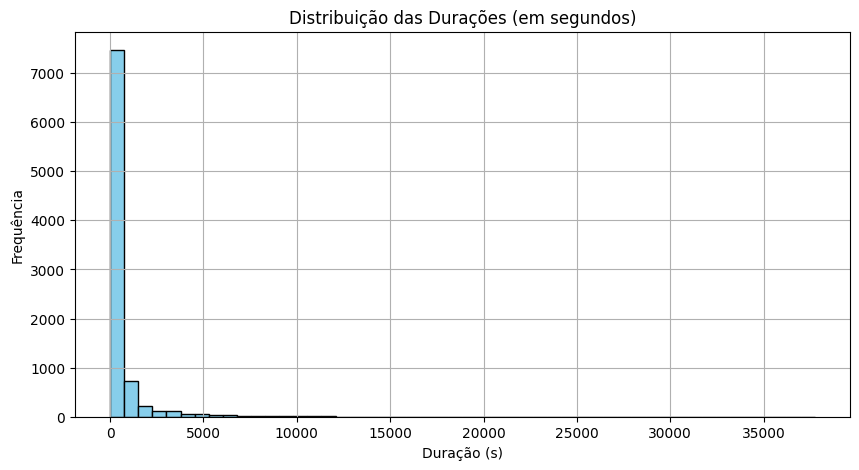

In [6]:
# Histograma 
plt.figure(figsize=(10, 5))
plt.hist(df_limpo["duracao_segundos"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribuição das Durações (em segundos)")
plt.xlabel("Duração (s)")
plt.ylabel("Frequência")
plt.grid(True)
plt.show()

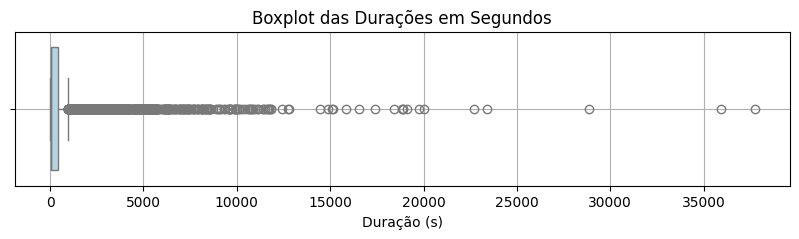

In [7]:
# Visualizar Outliers

plt.figure(figsize=(10, 2))
sns.boxplot(x=df_limpo["duracao_segundos"], color="lightblue")
plt.title("Boxplot das Durações em Segundos")
plt.xlabel("Duração (s)")
plt.grid(True)
plt.show()

Frequência de Amostragem

In [8]:
df_limpo["frequencia_amostragem"].describe()

count     8952.0
mean     48000.0
std          0.0
min      48000.0
25%      48000.0
50%      48000.0
75%      48000.0
max      48000.0
Name: frequencia_amostragem, dtype: float64

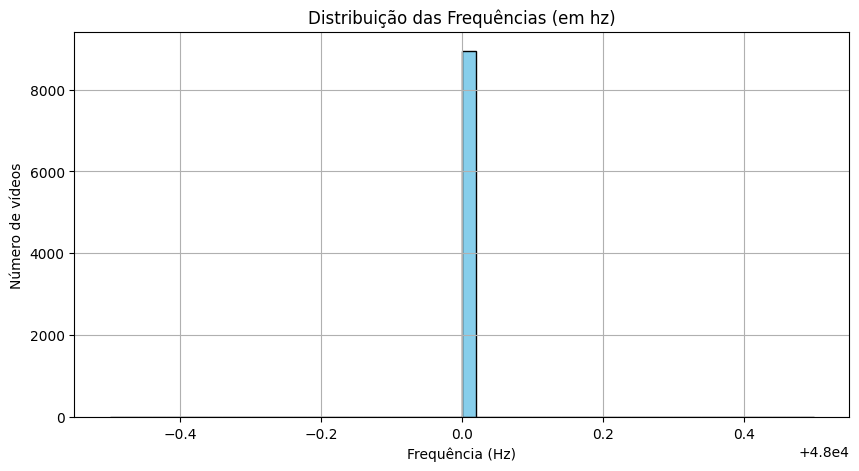

In [9]:
# Histograma 
plt.figure(figsize=(10, 5))
plt.hist(df_limpo["frequencia_amostragem"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribuição das Frequências (em hz)")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Número de vídeos")
plt.grid(True)
plt.show()

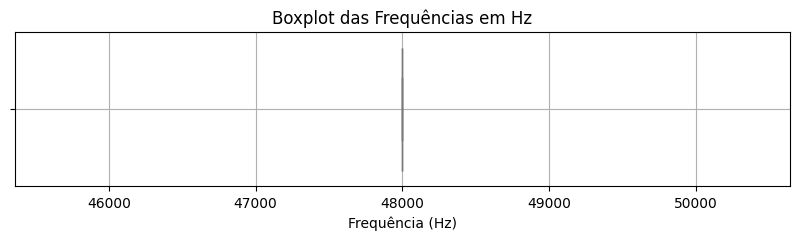

In [10]:
# Visualizar Outliers

plt.figure(figsize=(10, 2))
sns.boxplot(x=df_limpo["frequencia_amostragem"], color="lightblue")
plt.title("Boxplot das Frequências em Hz")
plt.xlabel("Frequência (Hz)")
plt.grid(True)
plt.show()

In [34]:
frequencias_unicas = df_limpo['frequencia_amostragem'].unique()
print("Frequências de amostragem únicas encontradas:")
print(frequencias_unicas)

Frequências de amostragem únicas encontradas:
[48000]


Amplitude Média

In [12]:
df_limpo["amplitude_media"].describe()

count    8952.000000
mean        0.078337
std         0.056327
min         0.000034
25%         0.040174
50%         0.064330
75%         0.097695
max         0.717396
Name: amplitude_media, dtype: float64

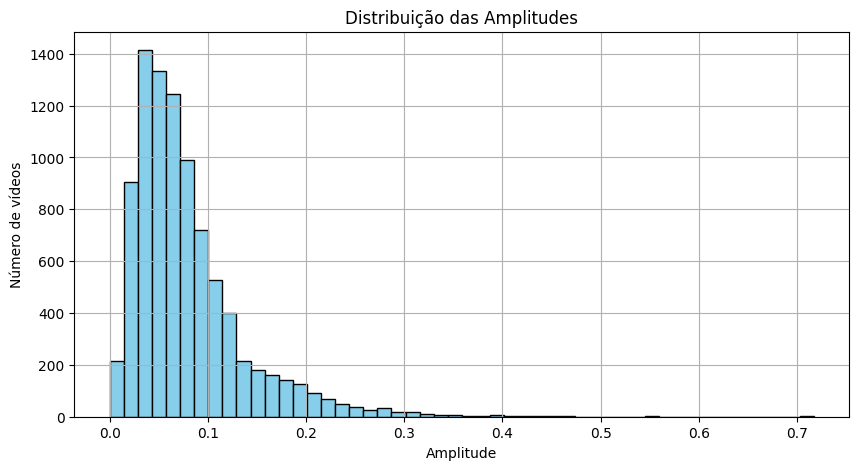

In [13]:
# Histograma 
plt.figure(figsize=(10, 5))
plt.hist(df_limpo["amplitude_media"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribuição das Amplitudes")
plt.xlabel("Amplitude")
plt.ylabel("Número de vídeos")
plt.grid(True)
plt.show()

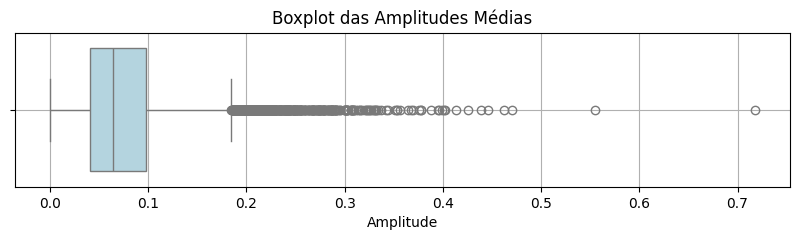

In [14]:
# Visualizar Outliers
plt.figure(figsize=(10, 2))
sns.boxplot(x=df_limpo["amplitude_media"], color="lightblue")
plt.title("Boxplot das Amplitudes Médias")
plt.xlabel("Amplitude")
plt.grid(True)
plt.show()

In [15]:
df_limpo[df_limpo['amplitude_media'] < 0.0435].head(40)
df_limpo[df_limpo['amplitude_media'] < 0.02].head(10)

,arquivo,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio,silencio/tempo
18,2-_50pF7U_Y.mp3,2226.432000,48000,0.007321,1.012636,0.007230,29.817684,0.045550,706,0.317099
21,EB43sgI9cSg.mp3,175.461604,48000,0.016143,0.345996,0.046656,24.730598,0.043936,4,0.022797
53,A-OUFSziCVA.mp3,698.752000,48000,0.006379,0.539578,0.011822,32.008244,0.051578,280,0.400714
61,KAE1JNu-eCA.mp3,164.385687,48000,0.007049,0.274494,0.025679,31.418022,0.095930,50,0.304163
71,9PVThI6OBG0.mp3,24.311312,48000,0.016104,0.421329,0.038223,21.536606,0.014922,2,0.082266
76,0zExQK2Lyiw.mp3,35.596208,48000,0.017790,0.388178,0.045830,23.519608,0.038787,1,0.028093
132,QXcwBNY3l98.mp3,620.112979,48000,0.019244,0.467172,0.041192,30.592735,0.096320,124,0.199964
155,THMixCVjABY.mp3,5.038750,48000,0.009150,0.058040,0.157650,160.695280,0.012644,0,0.000000
160,d2QinaqAJdM.mp3,521.566625,48000,0.016656,0.332616,0.050076,30.445824,0.068492,96,0.184061
183,ZnzJzMd0t00.mp3,1552.128000,48000,0.016194,0.262773,0.061627,26.618640,0.048166,39,0.025127


Amplitude Máxima

In [16]:
df_limpo["amplitude_maxima"].describe()

count    8952.000000
mean        0.849745
std         0.279211
min         0.000214
25%         0.651712
50%         0.921307
75%         1.047877
max         2.343787
Name: amplitude_maxima, dtype: float64

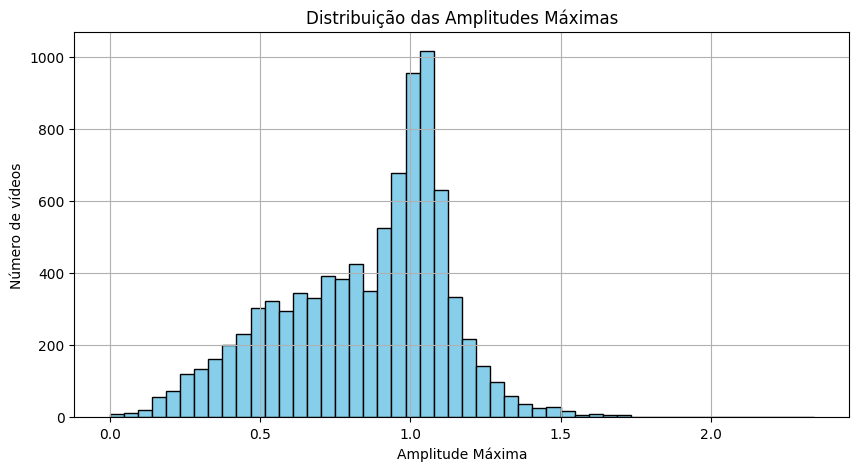

In [17]:
# Histograma 
plt.figure(figsize=(10, 5))
plt.hist(df_limpo["amplitude_maxima"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribuição das Amplitudes Máximas")
plt.xlabel("Amplitude Máxima")
plt.ylabel("Número de vídeos")
plt.grid(True)
plt.show()

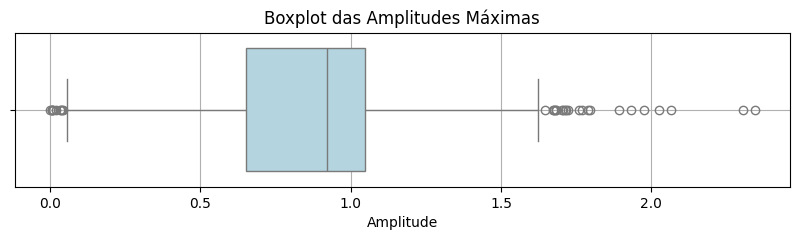

In [18]:
# Visualizar Outliers
plt.figure(figsize=(10, 2))
sns.boxplot(x=df_limpo["amplitude_maxima"], color="lightblue")
plt.title("Boxplot das Amplitudes Máximas")
plt.xlabel("Amplitude")
plt.grid(True)
plt.show()

In [19]:
df_limpo["amplitude_ratio (mean/max)"].describe()

count    8952.000000
mean        0.090351
std         0.048885
min         0.003097
25%         0.056577
50%         0.078839
75%         0.111637
max         0.498551
Name: amplitude_ratio (mean/max), dtype: float64

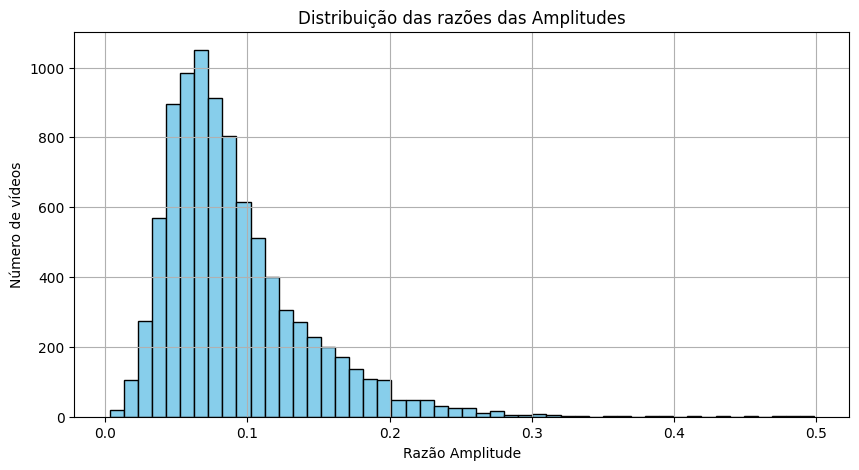

In [20]:
# Histograma 
plt.figure(figsize=(10, 5))
plt.hist(df_limpo["amplitude_ratio (mean/max)"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribuição das razões das Amplitudes")
plt.xlabel("Razão Amplitude")
plt.ylabel("Número de vídeos")
plt.grid(True)
plt.show()

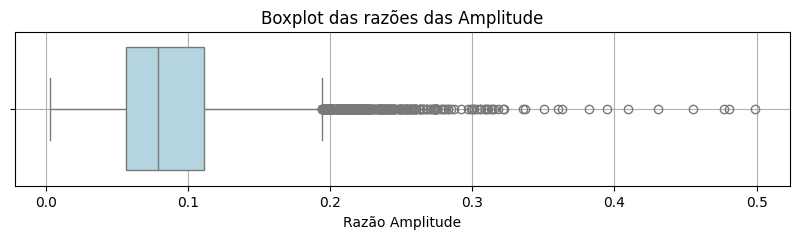

In [21]:
# Visualizar Outliers
plt.figure(figsize=(10, 2))
sns.boxplot(x=df_limpo["amplitude_ratio (mean/max)"], color="lightblue")
plt.title("Boxplot das razões das Amplitude")
plt.xlabel("Razão Amplitude")
plt.grid(True)
plt.show()

Signal to Noise

In [22]:
df_limpo["snr_estimado_db"].describe()

count    8952.000000
mean       32.939637
std        18.153202
min        13.541010
25%        25.527464
50%        29.030087
75%        34.169236
max       191.253780
Name: snr_estimado_db, dtype: float64

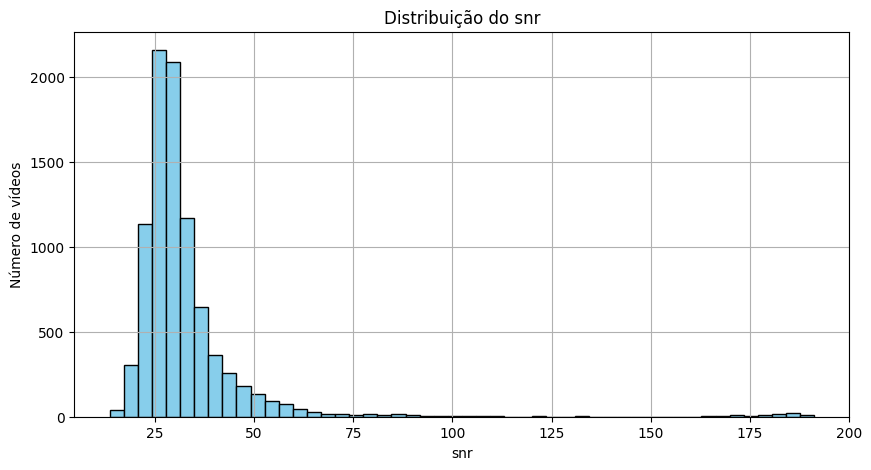

In [23]:
# Histograma 
plt.figure(figsize=(10, 5))
plt.hist(df_limpo["snr_estimado_db"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribuição do snr")
plt.xlabel("snr")
plt.ylabel("Número de vídeos")
plt.grid(True)
plt.show()

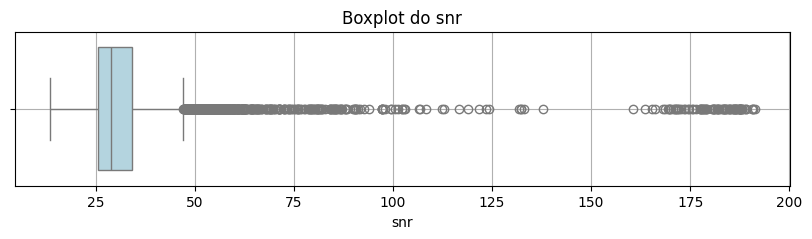

In [24]:
# Visualizar Outliers
plt.figure(figsize=(10, 2))
sns.boxplot(x=df_limpo["snr_estimado_db"], color="lightblue")
plt.title("Boxplot do snr")
plt.xlabel("snr")
plt.grid(True)
plt.show()

In [25]:
snr_menor_20 = df_limpo[df_limpo["snr_estimado_db"] < 20].shape[0]
print(f"Número de vídeos com snr < 20 dB: {snr_menor_20}")

df_limpo[df_limpo["snr_estimado_db"] < 20].head()

snr_menor_10 = df_limpo[df_limpo["snr_estimado_db"] < 10].shape[0]
print(f"Número de vídeos com snr < 10 dB: {snr_menor_10}")

df_limpo[df_limpo["snr_estimado_db"] < 10].head()

Número de vídeos com snr < 20 dB: 234
Número de vídeos com snr < 10 dB: 0


,arquivo,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio,silencio/tempo


Zero Crossing Rate

In [26]:
df_limpo["zero_crossing_rate"].describe()

count    8952.000000
mean        0.053387
std         0.016733
min         0.001279
25%         0.042082
50%         0.052360
75%         0.063092
max         0.163232
Name: zero_crossing_rate, dtype: float64

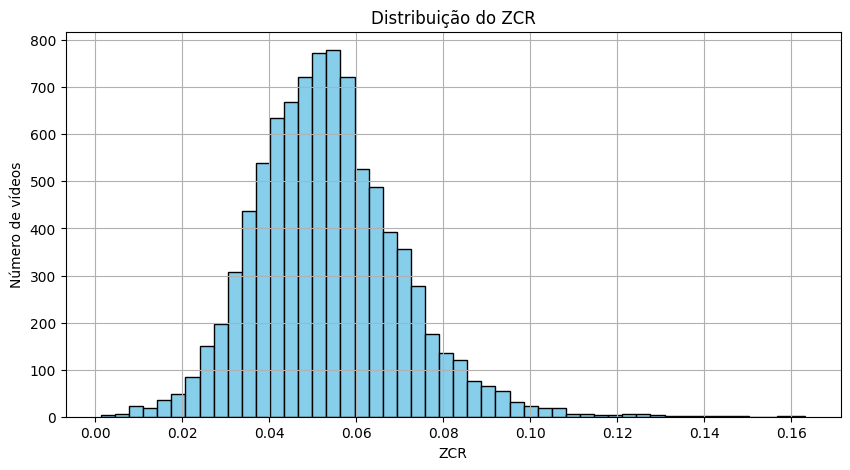

In [27]:
# Histograma 
plt.figure(figsize=(10, 5))
plt.hist(df_limpo["zero_crossing_rate"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribuição do ZCR")
plt.xlabel("ZCR")
plt.ylabel("Número de vídeos")
plt.grid(True)
plt.show()

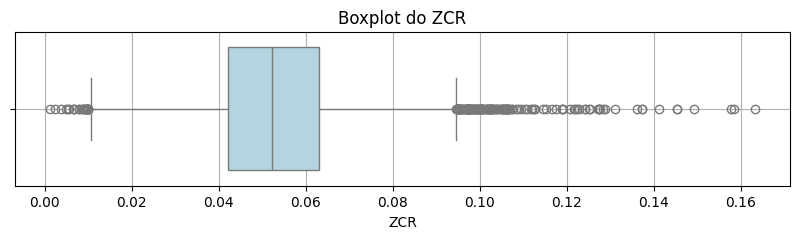

In [28]:
# Visualizar Outliers
plt.figure(figsize=(10, 2))
sns.boxplot(x=df_limpo["zero_crossing_rate"], color="lightblue")
plt.title("Boxplot do ZCR")
plt.xlabel("ZCR")
plt.grid(True)
plt.show()

In [29]:
zcr_maior_0_2 = df_limpo[df_limpo["zero_crossing_rate"] > 0.2].shape[0]
print(f"Número de vídeos com zcr > 0.2: {zcr_maior_0_2}")

df_limpo[df_limpo["zero_crossing_rate"] > 0.2].head()

Número de vídeos com zcr > 0.2: 0


,arquivo,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio,silencio/tempo


Regiões de Silêncio

In [30]:
df_limpo["regioes_silencio"].describe()

count     8952.000000
mean        99.795018
std        403.650194
min          0.000000
25%          0.000000
50%          2.000000
75%         24.000000
max      12850.000000
Name: regioes_silencio, dtype: float64

Regiões de Silêncio Normalizadas

In [31]:
df_limpo["silencio/tempo"].describe()

count    8952.000000
mean        0.083330
std         0.106394
min         0.000000
25%         0.000000
50%         0.026899
75%         0.153051
max         0.703125
Name: silencio/tempo, dtype: float64

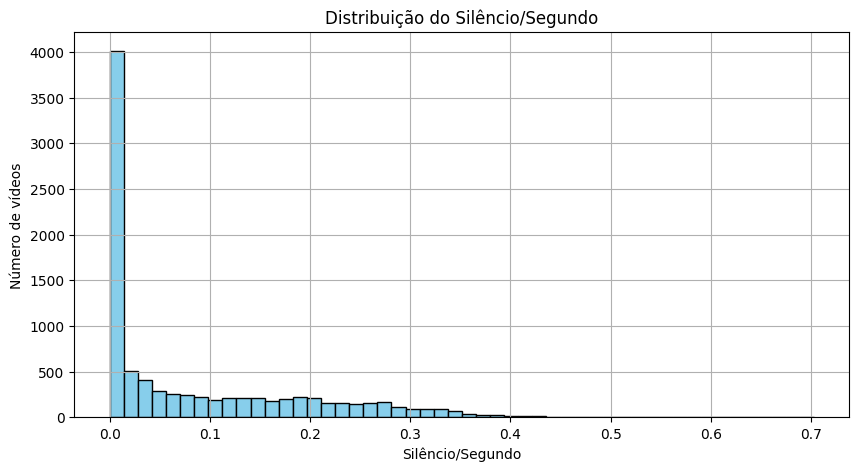

In [32]:
# Histograma 
plt.figure(figsize=(10, 5))
plt.hist(df_limpo["silencio/tempo"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribuição do Silêncio/Segundo")
plt.xlabel("Silêncio/Segundo")
plt.ylabel("Número de vídeos")
plt.grid(True)
plt.show()

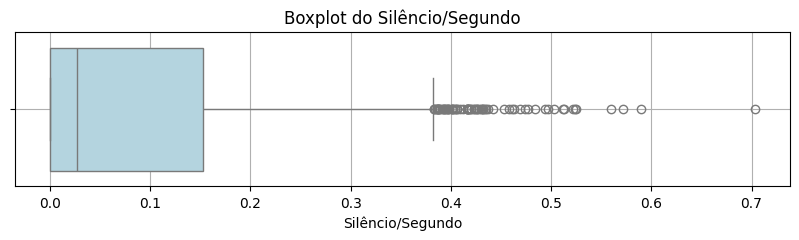

In [33]:
# Visualizar Outliers
plt.figure(figsize=(10, 2))
sns.boxplot(x=df_limpo["silencio/tempo"], color="lightblue")
plt.title("Boxplot do Silêncio/Segundo")
plt.xlabel("Silêncio/Segundo")
plt.grid(True)
plt.show()